# Question 1: Setup

You started working with the Capital Bike Share dataset in Homework 2 and 3. We're going to extend our work there to try to predict ridership.

Our basic goal will be to try to predict ridership in 2012 based on ridership data in 2011. So the 2011 data will be our *training set* and the 2012 data will be our *test set* (aka *held-out* data or sometimes *validation* data).

First, we'll load up the data.

In [132]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

# Set some display settings.
sns.set(context='notebook')

In [133]:
hourly_counts_orig = pd.read_csv('data/hour.csv')
print(len(hourly_counts_orig), "observations")
hourly_counts_orig.head()

17379 observations


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Renaming
Some of those column names are pretty awful. Let's fix a few of them up.

In [134]:
hourly_counts = hourly_counts_orig.rename(columns={
    'dteday': 'date',
    'hr': "hour",
    'mnth': "month",
    'weekday': "day_of_week",
    'holiday': "is_holiday",
    'workingday': "is_workingday",

    'weathersit': "precip_type",
    "hum": "humidity",
    'cnt': "rides"
}).drop(["instant", "casual", "registered"], axis=1)
hourly_counts['day_of_year'] = pd.to_datetime(hourly_counts['date']).dt.dayofyear

# Rearrange the column order
hourly_counts = hourly_counts[['date', 'day_of_year', 'season', 'yr', 'day_of_week', 'month',
       'hour', 'is_holiday', 'is_workingday', 'precip_type', 'temp', 'atemp',
       'humidity', 'windspeed', 'rides']]
hourly_counts.head()

,date,day_of_year,season,yr,day_of_week,month,hour,is_holiday,is_workingday,precip_type,temp,atemp,humidity,windspeed,rides
0,2011-01-01,1,1,0,6,1,0,0,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,1,0,6,1,1,0,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,1,0,6,1,2,0,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,1,0,6,1,3,0,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,1,0,6,1,4,0,0,1,0.24,0.2879,0.75,0.0,1


In [135]:
assert hourly_counts['hour'].max() == 23
assert hourly_counts['rides'].max() > 900

# HACK!
Since the bike share program was overall more popular in 2012 than in 2011, predicting based on 2011 data will systematically under-predict ridership in 2012. More advanced modeling and validation techniques can handle this shift directly, but for now we'll do this little hack to make our current tools work. (Only do this in real life if you have a *really* good explanation for why, and be *totally* transparent about it if you do.)

There were many more rides in 2012 than in 2011.

In [136]:
hourly_counts.groupby('yr').rides.sum()

yr
0    1243103
1    2049576
Name: rides, dtype: int64

To make things comparable, let's normalize by popularity. Of course we wouldn't actually *know* the total popularity of 2012 during that year, which is why this particular approach is labeled "HACK!".

In [137]:
year_means = hourly_counts.groupby('yr').rides.sum()
ratio = year_means[1] / year_means[0]
print("Scaling test set by", ratio)

hourly_counts['rides'] = np.where(hourly_counts.yr == 0, hourly_counts.rides, hourly_counts.rides / ratio)
print(hourly_counts.groupby('yr').rides.mean())

Scaling test set by 1.6487579870694544
yr
0    143.794448
1    142.329173
Name: rides, dtype: float64


## Train-Test Split
We're going to use 2011 as the training set and 2012 as the test set.

In [138]:
train = hourly_counts[hourly_counts.yr == 0]
test = hourly_counts[hourly_counts.yr == 1]

In [139]:
assert train['date'].iloc[0] == '2011-01-01'
assert test['date'].iloc[0] == '2012-01-01'
assert all(train['date'].str.startswith('2011'))
assert all(test['date'].str.startswith('2012'))
assert len(train) + len(test) == len(hourly_counts)

In [140]:
train.drop(["yr"], axis=1).head()

,date,day_of_year,season,day_of_week,month,hour,is_holiday,is_workingday,precip_type,temp,atemp,humidity,windspeed,rides
0,2011-01-01,1,1,6,1,0,0,0,1,0.24,0.2879,0.81,0.0,16.0
1,2011-01-01,1,1,6,1,1,0,0,1,0.22,0.2727,0.80,0.0,40.0
2,2011-01-01,1,1,6,1,2,0,0,1,0.22,0.2727,0.80,0.0,32.0
3,2011-01-01,1,1,6,1,3,0,0,1,0.24,0.2879,0.75,0.0,13.0
4,2011-01-01,1,1,6,1,4,0,0,1,0.24,0.2879,0.75,0.0,1.0


In [141]:
hourly_counts['date'] = pd.to_datetime(hourly_counts['date'])

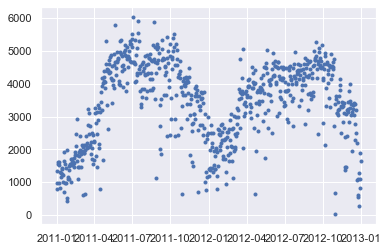

In [142]:
plt.plot(hourly_counts.groupby('date').rides.sum(), '.')

# Single Predictor

Does temperature affect ridership? Let's make a quick plot (we did this already last homework)

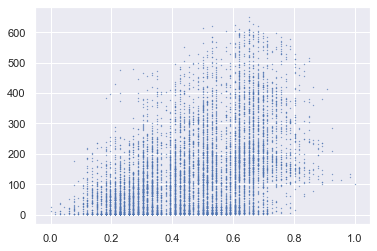

In [144]:
plt.scatter(train['atemp'], train['rides'], s=.1)

In [99]:
def transform(data):
    X = data[['atemp']]
    y = data['rides']
    return X, y
train_X, train_y = transform(train)
test_X, test_y = transform(test)

In [100]:
temp_only_model = LinearRegression().fit(train_X, train_y)

In [101]:
temp_only_model.coef_

array([338.37707325])

In [102]:
def show_scores(train_y, train_y_pred, test_y, test_y_pred):
    print("Training set MSE={:.2f}, r2={:.3f}".format(
        metrics.mean_squared_error(train_y, train_y_pred),
        metrics.r2_score(train_y, train_y_pred)
    ))
    print("Test set MSE={:.2f}, r2={:.3f}".format(
        metrics.mean_squared_error(test_y, test_y_pred),
        metrics.r2_score(test_y, test_y_pred)
    ))

train_y_pred = temp_only_model.predict(train_X)
test_y_pred = temp_only_model.predict(test_X)
    
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=14322.80, r2=0.200
Test set MSE=13863.20, r2=0.154


## Add in `month` as a continuous predictor

In [103]:
def transform(data):
    X = data[['atemp', 'month']]
    y = data['rides']
    return X, y
train_X, train_y = transform(train)
test_X, test_y = transform(test)

In [104]:
temp_and_month_model = LinearRegression().fit(train_X, train_y)

train_y_pred = temp_and_month_model.predict(train_X)
test_y_pred = temp_and_month_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)


Training set MSE=14259.13, r2=0.203
Test set MSE=13826.68, r2=0.156


# Add in `month` as a one-hot predictor

In [106]:
months = sorted(set(train['month']))
months

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [107]:
def transform(data):
    X = data[['atemp']].copy()
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    return X

train_X = transform(train)
train_y = train['rides']
test_X = transform(test)
test_y = test['rides']
train_X.head()

,atemp,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
temp_and_month_model = LinearRegression().fit(train_X, train_y)

train_y_pred = temp_and_month_model.predict(train_X)
test_y_pred = temp_and_month_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)


Training set MSE=13795.07, r2=0.229
Test set MSE=13338.74, r2=0.186


# If a column per month is better, how about one for each day?

In [111]:
dates = sorted(set(train['date']))

In [112]:
def transform(data):
    X = data[['atemp']].copy()
    dates_to_use = dates[1:] # drop the first one, since it's redundant.
    for date in dates_to_use:
        X[f'date_{date}'] = (data['date'] == date).astype(float)
    return X

train_X = transform(train)
train_y = train['rides']
test_X = transform(test)
test_y = test['rides']
train_X.head()

,atemp,date_2011-01-02,date_2011-01-03,date_2011-01-04,date_2011-01-05,date_2011-01-06,date_2011-01-07,date_2011-01-08,date_2011-01-09,date_2011-01-10,...,date_2011-12-22,date_2011-12-23,date_2011-12-24,date_2011-12-25,date_2011-12-26,date_2011-12-27,date_2011-12-28,date_2011-12-29,date_2011-12-30,date_2011-12-31
0,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
train_X.shape

(8645, 365)

In [116]:
temp_and_date_model = LinearRegression().fit(train_X, train_y)
train_y_pred = temp_and_date_model.predict(train_X)
test_y_pred = temp_and_date_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=11268.52, r2=0.370
Test set MSE=30111.80, r2=-0.838


What happened?

# Convert temperature units

According to the data page, `atemp` is:
```
	- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale) 
```

So to get back the temperature in degrees C, we'd use atemp * (50 - (-16)) + (-16).

In [150]:
def transform(data):
    X = data[['atemp']].copy()
    X['atemp'] = X['atemp'] * (50 - (-16)) + (-16)
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=13795.07, r2=0.229
Test set MSE=13098.41, r2=0.184


How does the model performance compare with the previous `temp_and_month` model? Can you explain that observation?

*your answer here*

# Add a polynomial term for `atemp`

Since very hot temperatures may result in decreased ridership, let's permit the relationship between temperature and ridership to be non-linear. Let's add a simple nonlinearity: a 2nd-degree polynomial term (i.e., x^2).

In [149]:
def transform(data):
    X = data[['atemp']].copy()
    X['atemp^2'] = X['atemp'] ** 2
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=13578.16, r2=0.241
Test set MSE=12945.90, r2=0.194
